<a href="https://colab.research.google.com/github/Anh-cuong/Hoc_May/blob/main/Tuan_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tổng số mẫu: 14
    outlook  temp humidity  windy play
0     sunny   hot     high  false   no
1     sunny   hot     high   true   no
2  overcast   hot     high  false  yes
3     rainy  mild     high  false  yes
4     rainy  cool   normal  false  yes


Entropy gốc E(S): 0.940
Gain(outlook ) = 0.247
Gain(temp    ) = 0.029
Gain(humidity) = 0.152
Gain(windy   ) = 0.048

--- Nhánh Sunny ---
Gain(temp    ) = 0.571
Gain(humidity) = 0.971
Gain(windy   ) = 0.020

--- Nhánh Rainy ---
Gain(temp    ) = 0.020
Gain(humidity) = 0.020
Gain(windy   ) = 0.971


Cấu trúc cây ID3 (dạng text):
outlook = overcast
    → play = yes
outlook = rainy
    windy = false
        → play = yes
    windy = true
        → play = no
outlook = sunny
    humidity = high
        → play = no
    humidity = normal
        → play = yes


--- KẾT QUẢ DỰ ĐOÁN ---
X1 = (sunny, cool, normal, true) -> play = yes
X2 = (rainy, hot, high, false)  -> play = yes


Trực quan hóa cây quyết định:


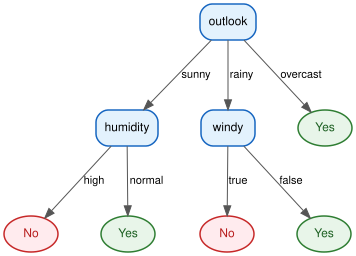

In [ ]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import graphviz
from IPython.display import display

# ==========================================
# 1. TẠO DỮ LIỆU BÀI TOÁN (14 MẪU)
# ==========================================
data = {
    'outlook': ['sunny', 'sunny', 'overcast', 'rainy', 'rainy', 'rainy', 'overcast',
                'sunny', 'sunny', 'rainy', 'sunny', 'overcast', 'overcast', 'rainy'],
    'temp': ['hot', 'hot', 'hot', 'mild', 'cool', 'cool', 'cool',
             'mild', 'cool', 'mild', 'mild', 'mild', 'hot', 'mild'],
    'humidity': ['high', 'high', 'high', 'high', 'normal', 'normal', 'normal',
                 'high', 'normal', 'normal', 'normal', 'high', 'normal', 'high'],
    'windy': ['false', 'true', 'false', 'false', 'false', 'true', 'true',
              'false', 'false', 'false', 'true', 'true', 'false', 'true'],
    'play': ['no', 'no', 'yes', 'yes', 'yes', 'no', 'yes',
             'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'no']
}

df = pd.DataFrame(data)
print(f"Tổng số mẫu: {len(df)}")
print(df.head())
print("\n" + "="*50 + "\n")

# ==========================================
# 2. CÔNG THỨC ENTROPY & INFORMATION GAIN
# ==========================================
def entropy(series):
    probs = series.value_counts(normalize=True)
    return -sum(p * math.log2(p) for p in probs)

def information_gain(df_sub, attr, target="play"):
    base = entropy(df_sub[target])
    weighted = sum(len(sub) / len(df_sub) * entropy(sub[target])
                   for _, sub in df_sub.groupby(attr))
    return base - weighted

print(f"Entropy gốc E(S): {entropy(df['play']):.3f}")
for a in ["outlook", "temp", "humidity", "windy"]:
    print(f"Gain({a:8s}) = {information_gain(df, a):.3f}")

sunny_sub = df[df["outlook"] == "sunny"]
rainy_sub = df[df["outlook"] == "rainy"]

print("\n--- Nhánh Sunny ---")
for a in ["temp", "humidity", "windy"]:
    print(f"Gain({a:8s}) = {information_gain(sunny_sub, a):.3f}")

print("\n--- Nhánh Rainy ---")
for a in ["temp", "humidity", "windy"]:
    print(f"Gain({a:8s}) = {information_gain(rainy_sub, a):.3f}")

print("\n" + "="*50 + "\n")

# ==========================================
# 3. THUẬT TOÁN XÂY DỰNG CÂY ID3 & DỰ ĐOÁN
# ==========================================
def id3(df_data, attrs, target="play"):
    labels = df_data[target]
    if labels.nunique() == 1:
        return labels.iloc[0]
    if not attrs:
        return labels.mode()[0]

    best = max(attrs, key=lambda a: information_gain(df_data, a, target))
    tree = {best: {}}
    rest = [a for a in attrs if a != best]
    for val, sub in df_data.groupby(best):
        tree[best][val] = id3(sub, rest, target)
    return tree

def print_tree(node, prefix=""):
    if isinstance(node, dict):
        attr = next(iter(node))
        for val, child in node[attr].items():
            print(f"{prefix}{attr} = {val}")
            print_tree(child, prefix + "    ")
    else:
        print(f"{prefix}→ play = {node}")

tree = id3(df, ["outlook", "temp", "humidity", "windy"])
print("Cấu trúc cây ID3 (dạng text):")
print_tree(tree)
print("\n" + "="*50 + "\n")

def classify(tree_dict, sample):
    node = tree_dict
    while isinstance(node, dict):
        attr = next(iter(node))
        val = str(sample.get(attr, '')).lower()
        if val not in node[attr]:
            return "Không xác định"
        node = node[attr][val]
    return node

# Kiểm thử 2 mẫu X1 và X2 từ bảng
X1 = {"outlook": "sunny", "temp": "cool", "humidity": "normal", "windy": "true"}
X2 = {"outlook": "rainy", "temp": "hot",  "humidity": "high",   "windy": "false"}

print("--- KẾT QUẢ DỰ ĐOÁN ---")
print("X1 = (sunny, cool, normal, true) -> play =", classify(tree, X1))
print("X2 = (rainy, hot, high, false)  -> play =", classify(tree, X2))
print("\n" + "="*50 + "\n")

# ==========================================
# 4. VẼ CÂY BẰNG GRAPHVIZ (GIỐNG TRÊN BẢNG)
# ==========================================
dot = graphviz.Digraph(comment='Decision Tree', format='png')
dot.attr('graph', rankdir='TB', nodesep='0.6', ranksep='0.8')
dot.attr('node', fontname='Helvetica', fontsize='12')
dot.attr('edge', fontname='Helvetica', fontsize='11', color='#555555')

# Các nút điều kiện
dot.node('outlook', 'outlook', shape='box', style='rounded,filled', fillcolor='#E3F2FD', color='#1565C0', penwidth='1.5')
dot.node('humidity', 'humidity', shape='box', style='rounded,filled', fillcolor='#E3F2FD', color='#1565C0', penwidth='1.5')
dot.node('windy', 'windy', shape='box', style='rounded,filled', fillcolor='#E3F2FD', color='#1565C0', penwidth='1.5')

# Các nút lá kết quả (Yes / No)
dot.node('leaf_sunny_no', 'No', shape='ellipse', style='filled', fillcolor='#FFEBEE', color='#C62828', fontcolor='#B71C1C', penwidth='1.5')
dot.node('leaf_sunny_yes', 'Yes', shape='ellipse', style='filled', fillcolor='#E8F5E9', color='#2E7D32', fontcolor='#1B5E20', penwidth='1.5')
dot.node('leaf_overcast_yes', 'Yes', shape='ellipse', style='filled', fillcolor='#E8F5E9', color='#2E7D32', fontcolor='#1B5E20', penwidth='1.5')
dot.node('leaf_rainy_no', 'No', shape='ellipse', style='filled', fillcolor='#FFEBEE', color='#C62828', fontcolor='#B71C1C', penwidth='1.5')
dot.node('leaf_rainy_yes', 'Yes', shape='ellipse', style='filled', fillcolor='#E8F5E9', color='#2E7D32', fontcolor='#1B5E20', penwidth='1.5')

# Liên kết cạnh
dot.edge('outlook', 'humidity', label=' sunny')
dot.edge('outlook', 'leaf_overcast_yes', label=' overcast')
dot.edge('outlook', 'windy', label=' rainy')

dot.edge('humidity', 'leaf_sunny_no', label=' high')
dot.edge('humidity', 'leaf_sunny_yes', label=' normal')

dot.edge('windy', 'leaf_rainy_no', label=' true')
dot.edge('windy', 'leaf_rainy_yes', label=' false')

print("Trực quan hóa cây quyết định:")
display(dot)